In [211]:
# Import the functions and class from your data loader file
from tensorflow.keras.optimizers import Adam

from data_loader import load_data, ImageDataGenerator
import matplotlib.pyplot as plt
import UNet
importlib.reload(UNet)

from UNet import unet_model, f1_metric

import importlib
import data_loader
importlib.reload(data_loader)

<module 'data_loader' from 'c:\\Users\\Lenovo\\Desktop\\this semester\\Deep Learning\\Project\\project_code\\data_loader.py'>

In [212]:
# Define the directories containing images and masks
image_dir = r"C:\Users\Lenovo\Desktop\this semester\Deep Learning\Project\79ca5c85-0d00-45fd-81e9-aa787898ebf5_epfml-segmentation\training\training\images"
mask_dir = r"C:\Users\Lenovo\Desktop\this semester\Deep Learning\Project\79ca5c85-0d00-45fd-81e9-aa787898ebf5_epfml-segmentation\training\training\groundtruth"

# Load the data (images and masks)
images, masks = load_data(image_dir, mask_dir, img_size=(400, 400))

train_images, val_images = images[:80], images[80:]
train_masks, val_masks = masks[:80], masks[80:]



In [213]:
print(f"train_images shape: {train_images.shape}")
print(f"train_masks shape: {train_masks.shape}")
print(f"val_images shape: {val_images.shape}")
print(f"val_masks shape: {val_masks.shape}")


train_images shape: (80, 400, 400, 1)
train_masks shape: (80, 400, 400, 1)
val_images shape: (20, 400, 400, 1)
val_masks shape: (20, 400, 400, 1)


In [214]:
# Assuming 'train_images' and 'train_masks' are numpy arrays
train_gen = ImageDataGenerator(train_images, train_masks, target_size=(512, 512), batch_size=32, augment=True)
val_gen = ImageDataGenerator(val_images, val_masks, target_size=(512, 512), batch_size=32, augment=False)

# Fetch a batch of images and masks
images, masks = train_gen[0]

print(f"Batch images shape: {images.shape}")
print(f"Batch masks shape: {masks.shape}")


Batch images shape: (32, 512, 512)
Batch masks shape: (32, 512, 512)


In [177]:
# Fetch a batch of images and masks
x_batch, y_batch = train_gen[0]

# Print the shapes of the batch
print(f"Batch images shape: {x_batch.shape}")  # Should print (16, 512, 512)
print(f"Batch masks shape: {y_batch.shape}")   # Should print (16, 512, 512)


Batch images shape: (32, 512, 512)
Batch masks shape: (32, 512, 512)


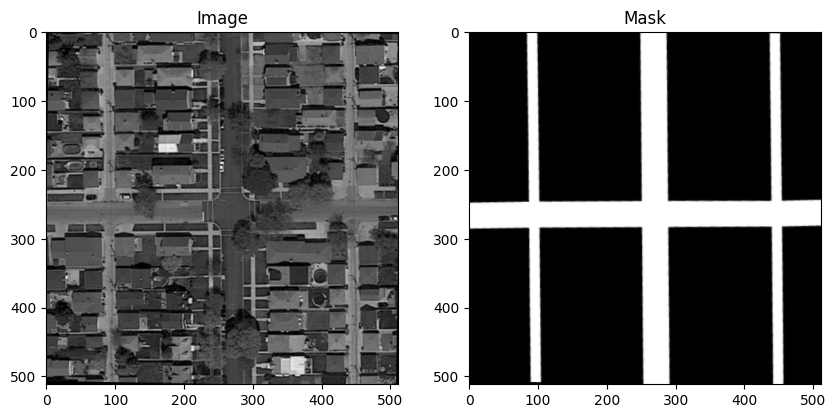

In [24]:
plt.figure(figsize=(10, 5))

# Show the first image
plt.subplot(1, 2, 1)
plt.imshow(x_batch[0], cmap='gray')
plt.title("Image")

# Show the first mask
plt.subplot(1, 2, 2)
plt.imshow(y_batch[0], cmap='gray')
plt.title("Mask")

plt.show()


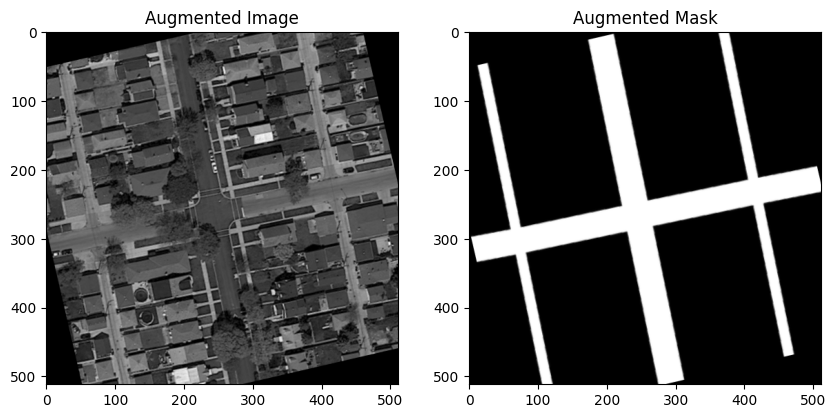

In [100]:
# Fetch a batch of augmented data
x_batch, y_batch = train_gen[0]

plt.figure(figsize=(10, 5))

# Show the first augmented image
plt.subplot(1, 2, 1)
plt.imshow(x_batch[0], cmap='gray')
plt.title("Augmented Image")

# Show the first augmented mask
plt.subplot(1, 2, 2)
plt.imshow(y_batch[0], cmap='gray')
plt.title("Augmented Mask")

plt.show()


In [101]:
print(f"Number of augmented images in the batch: {x_batch.shape[0]}")  

Number of augmented images in the batch: 32


In [209]:
model = unet_model(input_shape=(512, 512, 1), num_classes=1)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="binary_crossentropy",  # Corrected loss function for binary segmentation
              metrics=['accuracy', f1_metric])

# Train the model
history = model.fit(train_gen, validation_data=val_gen, epochs=50, steps_per_epoch=len(train_gen), validation_steps=len(val_gen))



Epoch 1/50


ValueError: Cannot take the length of shape with unknown rank.

In [117]:
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 512, 512,  │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 512, 512,  │          0 │ conv2d_69[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 512, 512,  │      9,248 │ activation_68[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 512, 512,  │          0 │ conv2d_70[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 256, 256,  │          0 │ activation_69[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 256, 256,  │     36,992 │ max_pooling2d_24… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 256, 256,  │          0 │ conv2d_71[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 256, 256,  │    147,584 │ activation_70[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_71       │ (None, 256, 256,  │          0 │ conv2d_72[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, 128, 128,  │          0 │ activation_71[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_25… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 128, 128,  │          0 │ conv2d_73[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 128, 128,  │    590,080 │ activation_72[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 128, 128,  │          0 │ conv2d_74[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 64, 64,    │          0 │ activation_73[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_26

 Total params: 92,598,821 (353.24 MB)

 Trainable params: 30,866,273 (117.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,732,548 (235.49 MB)

In [215]:
x_batch, y_batch = next(train_gen)  # or any batch from train_gen
print(f"Batch images shape: {x_batch.shape}")  # Should print (batch_size, 512, 512, 1)
print(f"Batch masks shape: {y_batch.shape}")   # Should print (batch_size, 512, 512, 1)


TypeError: 'ImageDataGenerator' object is not an iterator